# TMDb 5000 Movie Dataset Analysis

## Project Overview
This notebook analyzes the TMDb 5000 Movie Dataset from Kaggle. As a business analyst consultant, we will:
1. Understand the data structure
2. Clean and preprocess the data
3. Perform exploratory data analysis
4. Generate insights and visualizations

**Dataset**: TMDb 5000 Movies and Credits

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
from wordcloud import WordCloud, STOPWORDS
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Load Data

In [2]:
# Load datasets
movies = pd.read_csv('data/raw/tmdb_5000_movies.csv')
credits = pd.read_csv('data/raw/tmdb_5000_credits.csv')

print(f"Movies dataset shape: {movies.shape}")
print(f"Credits dataset shape: {credits.shape}")

Movies dataset shape: (4803, 20)
Credits dataset shape: (4803, 4)


## 3. Understand Data Structure

In [3]:
# Display movies dataset info
print("Movies Dataset:")
movies.head()

Movies Dataset:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [5]:
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [6]:
# Display credits dataset info
print("Credits Dataset:")
credits.head()

Credits Dataset:


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [7]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


## 4. Data Cleaning

In [8]:
# Rename credits columns for consistency
credits.rename(columns={'movie_id': 'id'}, inplace=True)

# Verify titles match between datasets
merged_check = movies[['id', 'title']].merge(credits[['id', 'title']], on='id', suffixes=('_movies', '_credits'))
title_mismatch = merged_check[merged_check['title_movies'] != merged_check['title_credits']]
print(f"Title mismatches: {len(title_mismatch)}")

Title mismatches: 0


In [9]:
# Merge datasets
df = movies.merge(credits[['id', 'cast', 'crew']], on='id')
print(f"Merged dataset shape: {df.shape}")

# Drop unnecessary columns
columns_to_drop = ['homepage', 'tagline', 'overview']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
print(f"Dataset shape after dropping columns: {df.shape}")

Merged dataset shape: (4803, 22)
Dataset shape after dropping columns: (4803, 19)


In [10]:
# Check for missing values
print("Missing values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Missing values:
release_date    1
runtime         2
dtype: int64


In [11]:
# Handle missing values
df = df.dropna(subset=['runtime', 'release_date'])
print(f"Dataset shape after handling missing values: {df.shape}")

Dataset shape after handling missing values: (4800, 19)


## 5. Data Type Conversion

In [12]:
# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year and month
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

print("Converted release_date to datetime and extracted year/month")
df[['release_date', 'release_year', 'release_month']].head()

Converted release_date to datetime and extracted year/month


,release_date,release_year,release_month
0,2009-12-10,2009,12
1,2007-05-19,2007,5
2,2015-10-26,2015,10
3,2012-07-16,2012,7
4,2012-03-07,2012,3


## 6. Data Format Conversion (Parse JSON columns)

In [13]:
def parse_json_column(column):
    """Parse JSON string column and extract names"""
    try:
        data = json.loads(column)
        if isinstance(data, list):
            return [item.get('name', '') for item in data if isinstance(item, dict)]
        return []
    except:
        return []

# Parse genres
df['genres_list'] = df['genres'].apply(parse_json_column)
df['genres_count'] = df['genres_list'].apply(len)
df['main_genre'] = df['genres_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# Parse keywords
df['keywords_list'] = df['keywords'].apply(parse_json_column)
df['keywords_count'] = df['keywords_list'].apply(len)

# Parse production companies
df['production_companies_list'] = df['production_companies'].apply(parse_json_column)
df['production_companies_count'] = df['production_companies_list'].apply(len)

# Parse cast
df['cast_list'] = df['cast'].apply(parse_json_column)
df['cast_count'] = df['cast_list'].apply(len)

print("Parsed JSON columns")
df[['title', 'genres_list', 'main_genre', 'keywords_count', 'cast_count']].head()

Parsed JSON columns


,title,genres_list,main_genre,keywords_count,cast_count
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",Action,21,83
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",Adventure,16,34
2,Spectre,"[Action, Adventure, Crime]",Action,7,83
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",Action,21,158
4,John Carter,"[Action, Adventure, Science Fiction]",Action,16,27


In [14]:
# Extract director from crew
def get_director(crew_json):
    """Extract director from crew"""
    try:
        crew = json.loads(crew_json)
        for member in crew:
            if member.get('job') == 'Director':
                return member.get('name', 'Unknown')
        return 'Unknown'
    except:
        return 'Unknown'

df['director'] = df['crew'].apply(get_director)
print("Extracted directors")
df[['title', 'director']].head(10)

Extracted directors


,title,director
0,Avatar,James Cameron
1,Pirates of the Caribbean: At World's End,Gore Verbinski
2,Spectre,Sam Mendes
3,The Dark Knight Rises,Christopher Nolan
4,John Carter,Andrew Stanton
5,Spider-Man 3,Sam Raimi
6,Tangled,Byron Howard
7,Avengers: Age of Ultron,Joss Whedon
8,Harry Potter and the Half-Blood Prince,David Yates
9,Batman v Superman: Dawn of Justice,Zack Snyder


## 7. Calculate Additional Metrics

In [15]:
# Calculate ROI (Return on Investment)
df['roi'] = ((df['revenue'] - df['budget']) / df['budget']) * 100
df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan)

# Calculate profit
df['profit'] = df['revenue'] - df['budget']

print(f"Final dataset shape: {df.shape}")
df[['title', 'budget', 'revenue', 'profit', 'roi']].head()

Final dataset shape: (4800, 33)


,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,1076.356577
1,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,220.333333
2,Spectre,245000000,880674609,635674609,259.459024
3,The Dark Knight Rises,250000000,1084939099,834939099,333.975640
4,John Carter,260000000,284139100,24139100,9.284269


## 8. Exploratory Data Analysis

### 8.1 Correlation Analysis

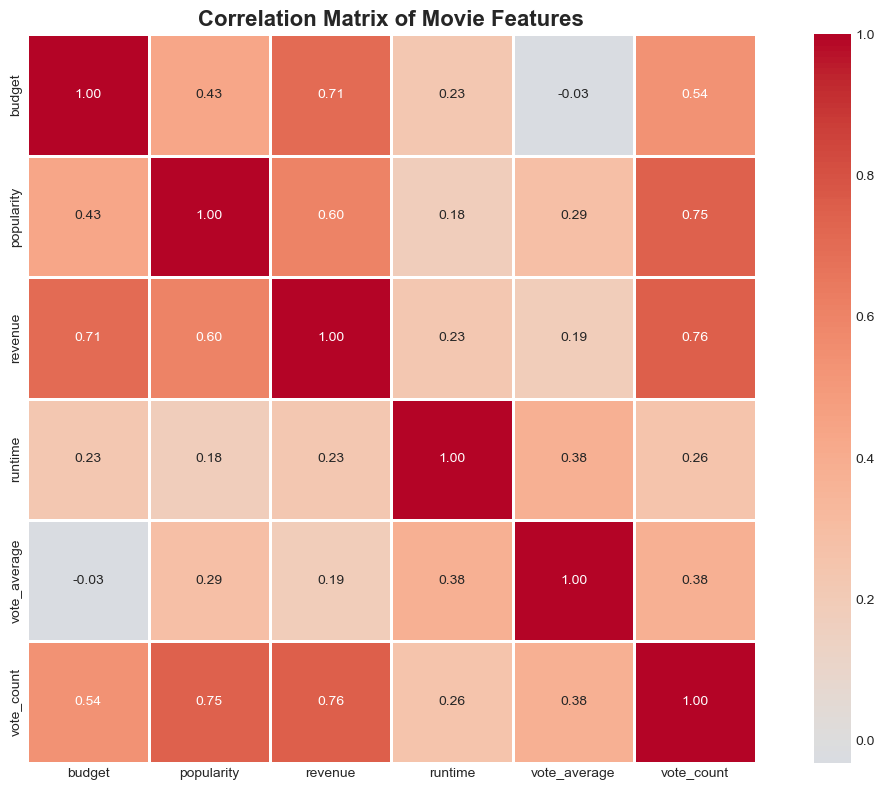

Key Findings:
- Budget has the strongest correlation with revenue
- Vote count and popularity are also positively correlated with revenue
- Runtime has a weak correlation with other features


In [16]:
# Filter data for visualization (remove movies with 0 budget/revenue)
df_viz = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
correlation_matrix = df_viz[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=1, square=True)
plt.title('Correlation Matrix of Movie Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Findings:")
print("- Budget has the strongest correlation with revenue")
print("- Vote count and popularity are also positively correlated with revenue")
print("- Runtime has a weak correlation with other features")

### 8.2 Budget vs Revenue Analysis

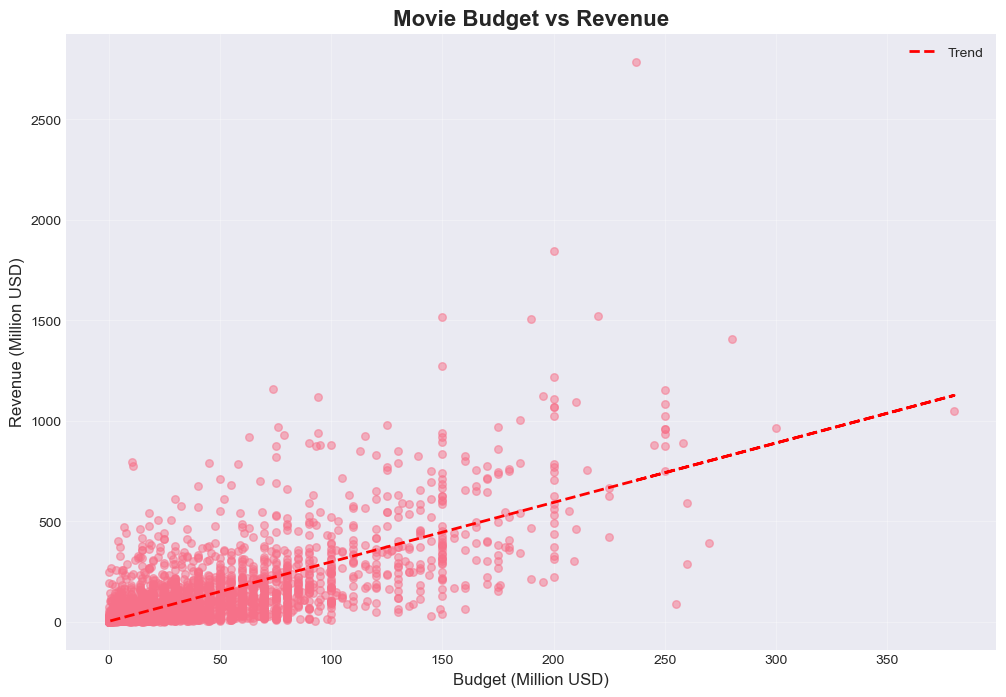

In [17]:
plt.figure(figsize=(12, 8))
plt.scatter(df_viz['budget'] / 1e6, df_viz['revenue'] / 1e6, alpha=0.5, s=30)
plt.xlabel('Budget (Million USD)', fontsize=12)
plt.ylabel('Revenue (Million USD)', fontsize=12)
plt.title('Movie Budget vs Revenue', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(df_viz['budget'], df_viz['revenue'], 1)
p = np.poly1d(z)
plt.plot(df_viz['budget'] / 1e6, p(df_viz['budget']) / 1e6, "r--", linewidth=2, label='Trend')
plt.legend()
plt.show()

### 8.3 Genre Analysis

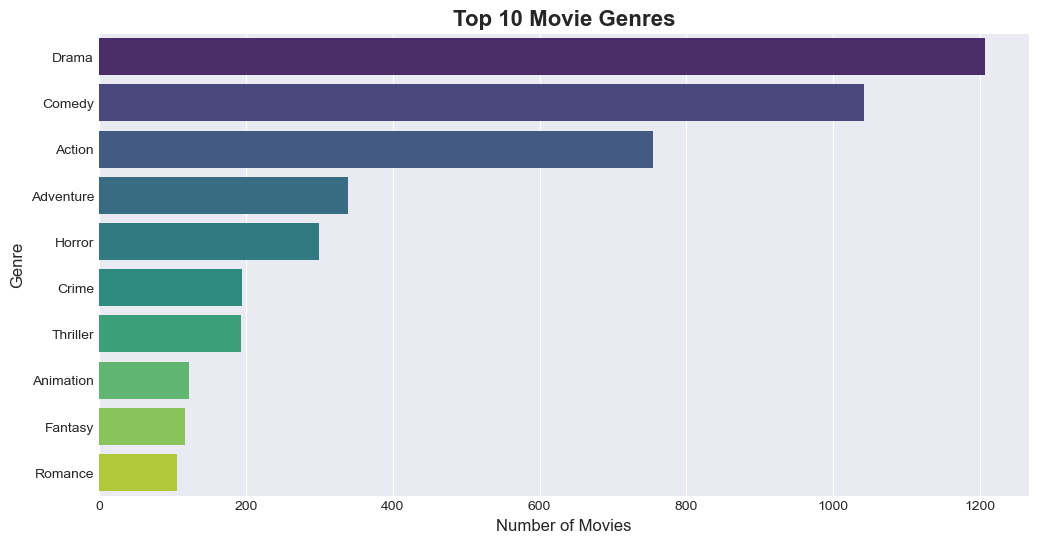

In [18]:
# Top genres by count
plt.figure(figsize=(12, 6))
genre_counts = df['main_genre'].value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Top 10 Movie Genres', fontsize=16, fontweight='bold')
plt.show()

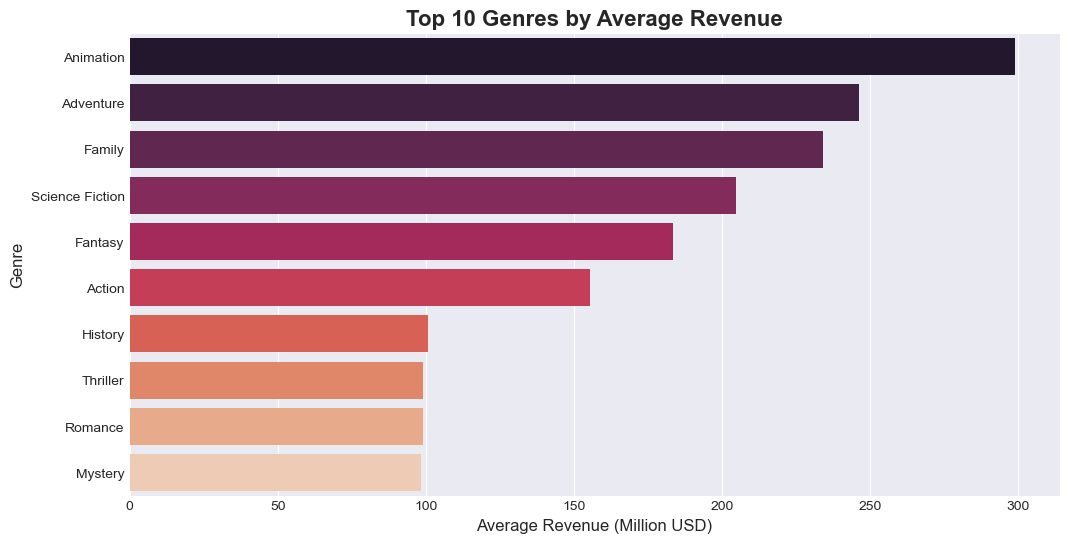

In [19]:
# Average revenue by genre
plt.figure(figsize=(12, 6))
genre_revenue = df_viz.groupby('main_genre')['revenue'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=genre_revenue.values / 1e6, y=genre_revenue.index, palette='rocket')
plt.xlabel('Average Revenue (Million USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Top 10 Genres by Average Revenue', fontsize=16, fontweight='bold')
plt.show()

### 8.4 Temporal Analysis

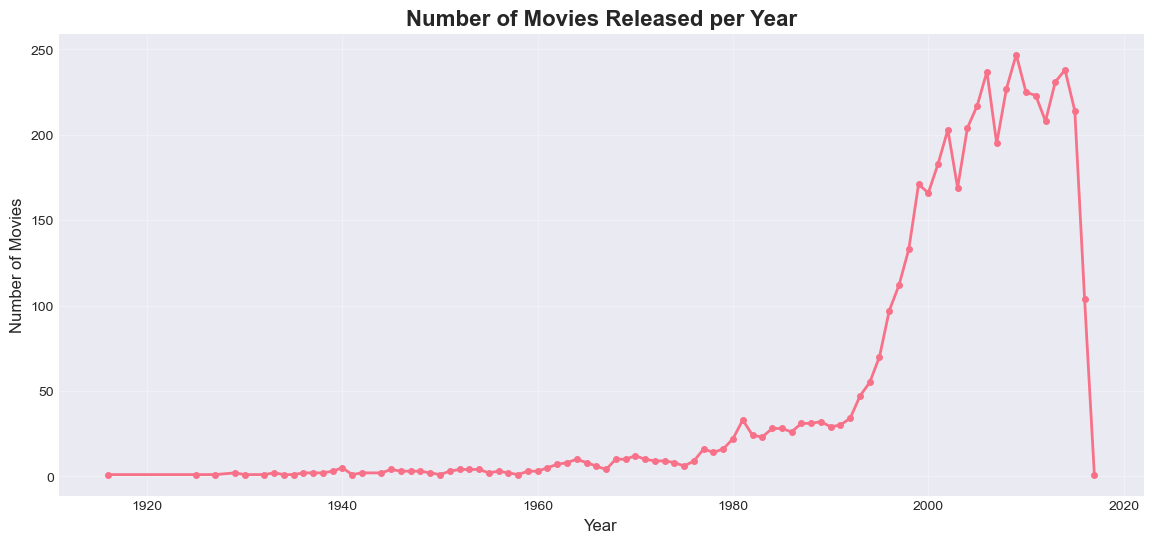

In [20]:
# Movies released per year
plt.figure(figsize=(14, 6))
movies_per_year = df['release_year'].value_counts().sort_index()
plt.plot(movies_per_year.index, movies_per_year.values, linewidth=2, marker='o', markersize=4)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.title('Number of Movies Released per Year', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

### 8.5 Runtime Distribution

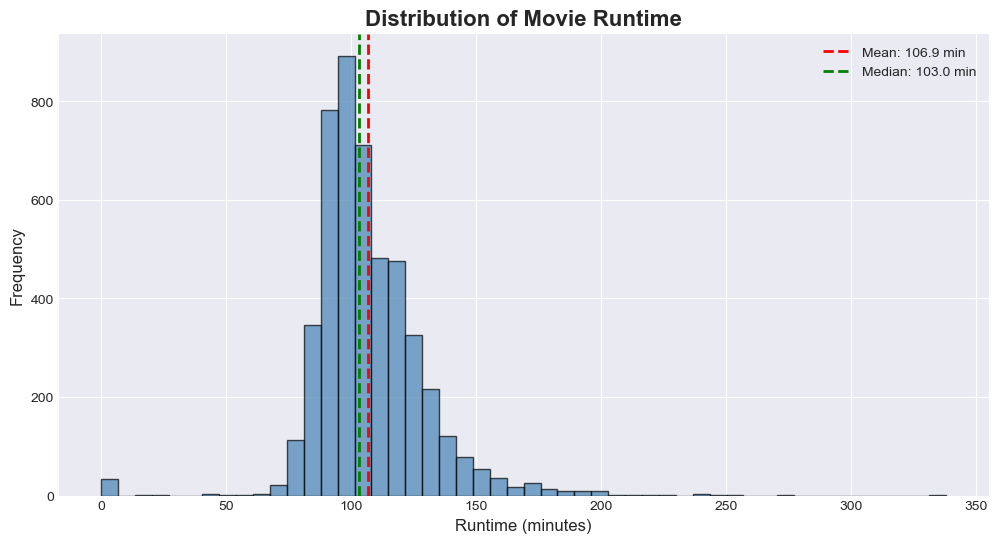

In [21]:
plt.figure(figsize=(12, 6))
plt.hist(df['runtime'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Movie Runtime', fontsize=16, fontweight='bold')
plt.axvline(df['runtime'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["runtime"].mean():.1f} min')
plt.axvline(df['runtime'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["runtime"].median():.1f} min')
plt.legend()
plt.show()

### 8.6 Most Profitable Movies

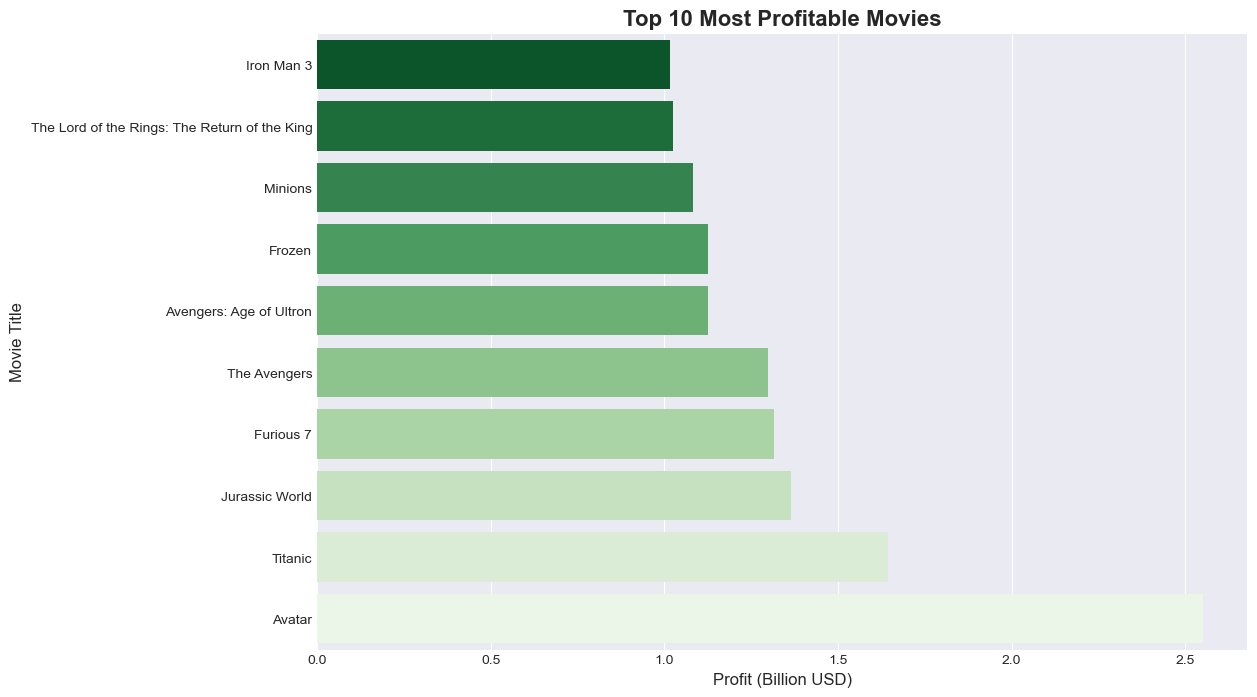

In [22]:
plt.figure(figsize=(12, 8))
top_profit = df_viz.nlargest(10, 'profit')[['title', 'profit']].sort_values('profit')
sns.barplot(x=top_profit['profit'] / 1e9, y=top_profit['title'], palette='Greens_r')
plt.xlabel('Profit (Billion USD)', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.title('Top 10 Most Profitable Movies', fontsize=16, fontweight='bold')
plt.show()

### 8.7 Vote Analysis

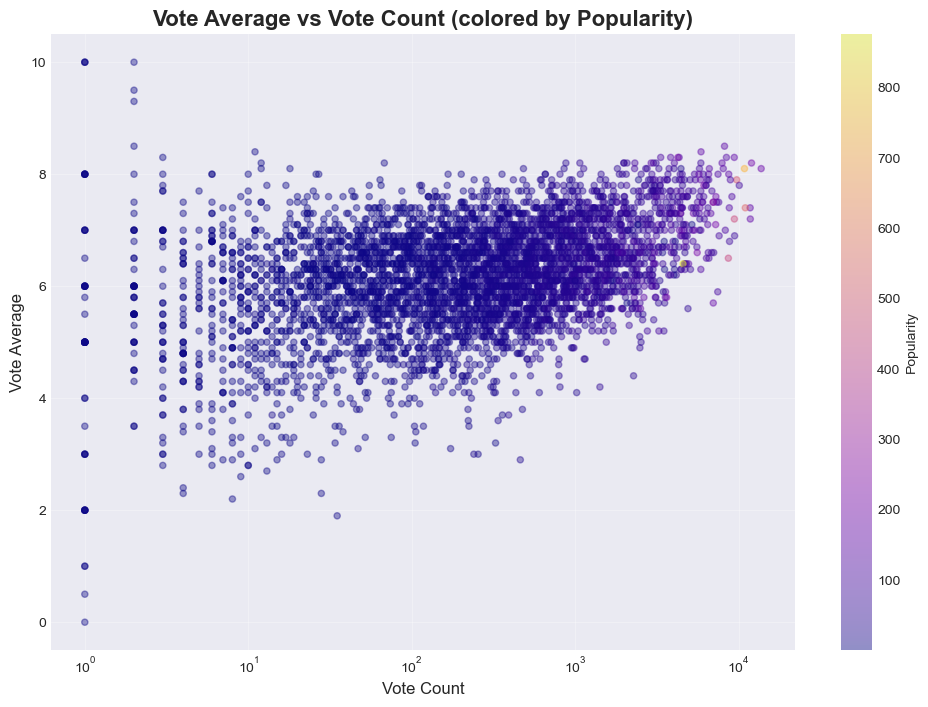

In [23]:
plt.figure(figsize=(12, 8))
plt.scatter(df['vote_count'], df['vote_average'], alpha=0.4, s=20, c=df['popularity'], cmap='plasma')
plt.xlabel('Vote Count', fontsize=12)
plt.ylabel('Vote Average', fontsize=12)
plt.title('Vote Average vs Vote Count (colored by Popularity)', fontsize=16, fontweight='bold')
plt.colorbar(label='Popularity')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

### 8.8 Keywords Word Cloud (关键词词云)
> 👤 **成员 B** — 基础推荐算法 & 工具库

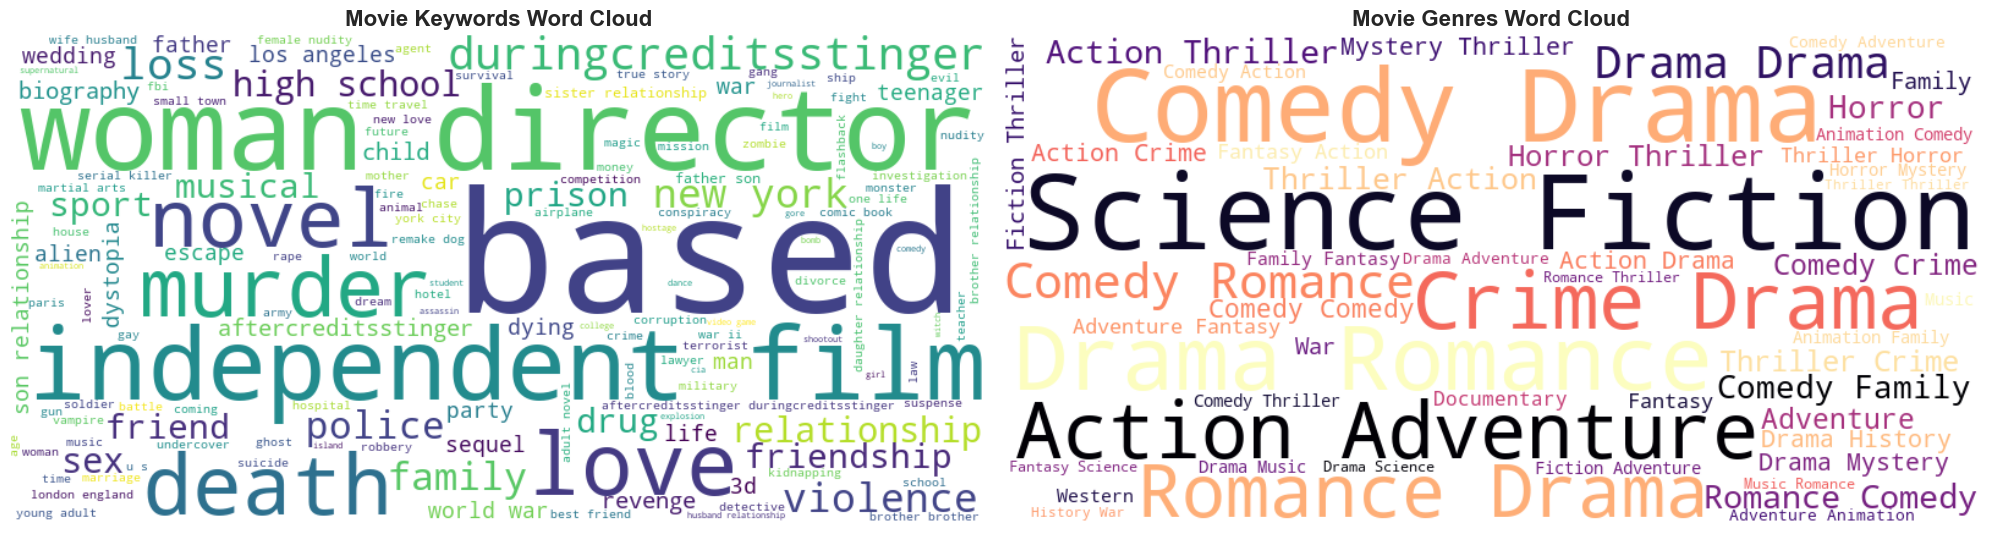

Total unique keywords: 9808
Top 10 keywords: {'woman director': 324, 'independent film': 318, 'duringcreditsstinger': 307, 'based on novel': 197, 'murder': 189, 'aftercreditsstinger': 170, 'violence': 150, 'dystopia': 139, 'sport': 126, 'revenge': 118}


In [24]:
# Keywords Word Cloud
all_keywords = []
for kw_list in df['keywords_list']:
    if isinstance(kw_list, list):
        all_keywords.extend(kw_list)

keyword_text = ' '.join(all_keywords)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Keywords word cloud
wordcloud_kw = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=150,
    colormap='viridis',
    stopwords=STOPWORDS,
    contour_width=1,
    contour_color='steelblue'
).generate(keyword_text)

axes[0].imshow(wordcloud_kw, interpolation='bilinear')
axes[0].set_title('Movie Keywords Word Cloud', fontsize=16, fontweight='bold')
axes[0].axis('off')

# Genre word cloud
all_genres = []
for g_list in df['genres_list']:
    if isinstance(g_list, list):
        all_genres.extend(g_list)

genre_text = ' '.join(all_genres)

wordcloud_genre = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=50,
    colormap='magma',
    stopwords=STOPWORDS,
    contour_width=1,
    contour_color='firebrick'
).generate(genre_text)

axes[1].imshow(wordcloud_genre, interpolation='bilinear')
axes[1].set_title('Movie Genres Word Cloud', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Total unique keywords: {len(set(all_keywords))}")
print(f"Top 10 keywords: {pd.Series(all_keywords).value_counts().head(10).to_dict()}")

## 9. Key Insights and Summary

In [25]:
print("=" * 50)
print("KEY INSIGHTS FROM TMDb MOVIE ANALYSIS")
print("=" * 50)

print(f"\n1. DATASET OVERVIEW")
print(f"   - Total Movies: {len(df)}")
print(f"   - Date Range: {df['release_year'].min():.0f} - {df['release_year'].max():.0f}")

print(f"\n2. FINANCIAL METRICS")
print(f"   - Average Budget: ${df_viz['budget'].mean() / 1e6:.2f}M")
print(f"   - Average Revenue: ${df_viz['revenue'].mean() / 1e6:.2f}M")
print(f"   - Budget-Revenue Correlation: {df_viz['budget'].corr(df_viz['revenue']):.3f}")

print(f"\n3. CONTENT METRICS")
print(f"   - Average Runtime: {df['runtime'].mean():.1f} minutes")
print(f"   - Average Vote: {df['vote_average'].mean():.2f}/10")
print(f"   - Most Common Genre: {df['main_genre'].mode()[0]}")

print("\n4. TOP 5 HIGHEST GROSSING MOVIES")
top_revenue = df_viz.nlargest(5, 'revenue')[['title', 'revenue', 'release_year']]
for idx, row in top_revenue.iterrows():
    print(f"   - {row['title']} ({row['release_year']:.0f}): ${row['revenue']/1e9:.2f}B")

print("\n5. TOP 5 HIGHEST ROI MOVIES")
top_roi = df_viz.nlargest(5, 'roi')[['title', 'roi', 'budget', 'revenue']]
for idx, row in top_roi.iterrows():
    print(f"   - {row['title']}: {row['roi']:.0f}% ROI")

print("\n6. TOP DIRECTORS (by movie count)")
director_counts = df['director'].value_counts().head(5)
for director, count in director_counts.items():
    if director != 'Unknown':
        print(f"   - {director}: {count} movies")

print("\n" + "=" * 50)

KEY INSIGHTS FROM TMDb MOVIE ANALYSIS

1. DATASET OVERVIEW
   - Total Movies: 4800
   - Date Range: 1916 - 2017

2. FINANCIAL METRICS
   - Average Budget: $40.65M
   - Average Revenue: $121.24M
   - Budget-Revenue Correlation: 0.705

3. CONTENT METRICS
   - Average Runtime: 106.9 minutes
   - Average Vote: 6.09/10
   - Most Common Genre: Drama

4. TOP 5 HIGHEST GROSSING MOVIES
   - Avatar (2009): $2.79B
   - Titanic (1997): $1.85B
   - The Avengers (2012): $1.52B
   - Jurassic World (2015): $1.51B
   - Furious 7 (2015): $1.51B

5. TOP 5 HIGHEST ROI MOVIES
   - Modern Times: 849999900% ROI
   - Nurse 3-D: 99999900% ROI
   - Paranormal Activity: 1288939% ROI
   - Tarnation: 532934% ROI
   - The Blair Witch Project: 413233% ROI

6. TOP DIRECTORS (by movie count)
   - Steven Spielberg: 27 movies
   - Woody Allen: 21 movies
   - Clint Eastwood: 20 movies
   - Martin Scorsese: 20 movies



## 10. Save Processed Data

In [26]:
# Save processed dataset
df.to_csv('tmdb_5000_processed.csv', index=False)
print("Saved processed dataset to: tmdb_5000_processed.csv")

Saved processed dataset to: tmdb_5000_processed.csv
